In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("E:\Data analysis projects\cricket_odi_analytics\data\odi_ball_by_ball.csv")

In [3]:
df.head()

,match_id,inning,over,ball,batter,bowler,non_striker,runs_batter,runs_total,extras,wicket,player_out,wicket_kind,team,ball_id,is_four,is_six,dot_ball,phase
0,1000887,1,0,1,DA Warner,Mohammad Amir,TM Head,0,0,0,0,NaN,NaN,Australia,1,0,0,1,Powerplay
1,1000887,1,0,2,DA Warner,Mohammad Amir,TM Head,0,0,0,0,NaN,NaN,Australia,2,0,0,1,Powerplay
2,1000887,1,0,3,DA Warner,Mohammad Amir,TM Head,0,0,0,0,NaN,NaN,Australia,3,0,0,1,Powerplay
3,1000887,1,0,4,DA Warner,Mohammad Amir,TM Head,0,0,0,0,NaN,NaN,Australia,4,0,0,1,Powerplay
4,1000887,1,0,5,DA Warner,Mohammad Amir,TM Head,0,1,1,0,NaN,NaN,Australia,5,0,0,0,Powerplay


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639277 entries, 0 to 1639276
Data columns (total 19 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   match_id     1639277 non-null  int64 
 1   inning       1639277 non-null  int64 
 2   over         1639277 non-null  int64 
 3   ball         1639277 non-null  int64 
 4   batter       1639277 non-null  object
 5   bowler       1639277 non-null  object
 6   non_striker  1639277 non-null  object
 7   runs_batter  1639277 non-null  int64 
 8   runs_total   1639277 non-null  int64 
 9   extras       1639277 non-null  int64 
 10  wicket       1639277 non-null  int64 
 11  player_out   44877 non-null    object
 12  wicket_kind  44877 non-null    object
 13  team         1639277 non-null  object
 14  ball_id      1639277 non-null  int64 
 15  is_four      1639277 non-null  int64 
 16  is_six       1639277 non-null  int64 
 17  dot_ball     1639277 non-null  int64 
 18  phase        1639277 n

#### `Bowling Dataset`

##### Runs conceded by bowler

In [5]:
runs_conceded = df.groupby("bowler")["runs_total"].sum()
runs_conceded.head()

bowler
A Ashok        120
A Athanaze      71
A Balbirnie     31
A Beggs        131
A Bohara        51
Name: runs_total, dtype: int64

#### Balls bowled

In [6]:
balls_bowled = df.groupby("bowler").size()
balls_bowled.head()

bowler
A Ashok         97
A Athanaze     129
A Balbirnie     24
A Beggs        136
A Bohara        66
dtype: int64

#### Wickets taken

In [7]:
wickets = df.groupby("bowler")["wicket"].sum()
wickets.head()

bowler
A Ashok        2
A Athanaze     5
A Balbirnie    1
A Beggs        5
A Bohara       1
Name: wicket, dtype: int64

#### Matches Played

In [8]:
matches_bowled = df.groupby("bowler")["match_id"].nunique()
matches_bowled.head()

bowler
A Ashok        3
A Athanaze     4
A Balbirnie    1
A Beggs        3
A Bohara       2
Name: match_id, dtype: int64

#### Innings Bowled

In [9]:
innings_bowled = (
    df.groupby(["bowler","match_id","inning"])
      .size()
      .reset_index()
      .groupby("bowler")
      .size()
)
innings_bowled.head()

bowler
A Ashok        3
A Athanaze     4
A Balbirnie    1
A Beggs        3
A Bohara       2
dtype: int64

#### `Bowling Stats Table`

In [10]:
bowling_stats = pd.DataFrame({
    "matches": matches_bowled,
    "innings": innings_bowled,
    "balls": balls_bowled,
    "runs_conceded": runs_conceded,
    "wickets": wickets
})

In [11]:
bowling_stats.head()

,matches,innings,balls,runs_conceded,wickets
bowler,,,,,
A Ashok,3,3,97,120,2
A Athanaze,4,4,129,71,5
A Balbirnie,1,1,24,31,1
A Beggs,3,3,136,131,5
A Bohara,2,2,66,51,1


In [12]:
bowling_stats.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1925 entries, A Ashok to Zulfiqar Babar
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   matches        1925 non-null   int64
 1   innings        1925 non-null   int64
 2   balls          1925 non-null   int64
 3   runs_conceded  1925 non-null   int64
 4   wickets        1925 non-null   int64
dtypes: int64(5)
memory usage: 90.2+ KB


In [13]:
# Check row by row
matches_vs_innings = bowling_stats['matches'] != bowling_stats['innings']
print(f"Rows where matches != innings: {matches_vs_innings.sum()}")
print(f"Total rows: {len(bowling_stats)}")

# Show the actual differences
if matches_vs_innings.any():
    print("\nRows with differences:")
    diff_rows = bowling_stats[matches_vs_innings][['matches', 'innings']]
    print(diff_rows.head(10))
else:
    print("✓ All rows have matches = innings")

Rows where matches != innings: 20
Total rows: 1925

Rows with differences:
               matches  innings
bowler                         
AC Kerr             82       83
AJ Hosein           40       41
B Muzarabani        47       48
DJS Dottin          46       47
HK Matthews         77       78
Harmeet Singh       20       21
Hassnain Shah        5        6
JC Archer           34       35
JJ Smit             36       37
JO Holder          127      128


#### super overs cheacking

In [14]:
# Check match 1388201 for Super Over characteristics
match_id = 1388201
match_df = df[df['match_id'] == match_id].copy()

# Analyze each inning's ball count
print(f"Match {match_id} Analysis:")
print("-" * 50)

for inning in sorted(match_df['inning'].unique()):
    inning_data = match_df[match_df['inning'] == inning]
    balls_in_inning = len(inning_data)
    max_over = inning_data['over'].max()
    teams = inning_data['team'].unique()
    
    print(f"\nInning {inning}:")
    print(f"  Teams: {teams}")
    print(f"  Balls bowled: {balls_in_inning}")
    print(f"  Max over: {max_over}")
    
    # Check if it looks like a Super Over (1 over, 6 balls)
    if max_over <= 1 and balls_in_inning <= 10:  # Super Over with wides/no-balls
        print(f"  ⚠️  This COULD be a Super Over!")
        
    # Check batting order
    batters = inning_data['batter'].unique()
    print(f"  Batters: {batters[:5]}...")

# Check for tied match indicators
# We would need match outcome from JSON

Match 1388201 Analysis:
--------------------------------------------------

Inning 1:
  Teams: ['New Zealand']
  Balls bowled: 307
  Max over: 49
  Batters: ['SW Bates' 'IC Gaze' 'AC Kerr' 'SFM Devine' 'ML Green']...

Inning 2:
  Teams: ['Pakistan']
  Balls bowled: 311
  Max over: 49
  Batters: ['Muneeba Ali' 'Sidra Ameen' 'Bismah Maroof' 'Aliya Riaz' 'Fatima Sana']...

Inning 3:
  Teams: ['Pakistan']
  Balls bowled: 6
  Max over: 0
  ⚠️  This COULD be a Super Over!
  Batters: ['Aliya Riaz' 'Fatima Sana']...

Inning 4:
  Teams: ['New Zealand']
  Balls bowled: 5
  Max over: 0
  ⚠️  This COULD be a Super Over!
  Batters: ['SFM Devine' 'AC Kerr' 'ML Green']...


#### Balls to Overs (1 over = 6 balls)

In [34]:
bowling_stats["overs"] = (bowling_stats["balls"] / 6).round(1)

#### Bowling Economy (economy = runs / overs)

In [35]:
bowling_stats["economy"] = (bowling_stats["runs_conceded"] / bowling_stats["overs"]).round(2)

#### Bowling Average (average = runs conceded / wickets)

In [36]:
bowling_stats["average"] = (bowling_stats["runs_conceded"] / bowling_stats["wickets"]).round(2)

#### Bowling Strike Rate (strike rate = balls / wickets)

In [37]:
bowling_stats["strike_rate"] = (bowling_stats["balls"] / bowling_stats["wickets"]).round(2)

#### Team for Bowler

In [38]:
match_teams = df.groupby("match_id")["team"].unique()
def get_bowler_team(row):
    teams = match_teams[row["match_id"]]
    
    for t in teams:
        if t != row["team"]:
            return t
        
df["bowling_team"] = df.apply(get_bowler_team, axis=1)


In [39]:
bowler_team = df.groupby("bowler")["bowling_team"].agg(lambda x: x.mode()[0])

bowling_stats["team"] = bowler_team

#### Reorder Columns

In [40]:
bowling_stats = bowling_stats[
[
"team",
"matches",
"innings",
"overs",
"balls",
"runs_conceded",
"wickets",
"economy",
"average",
"strike_rate"
]
]

#### Filter Serious Bowlers

In [ ]:
bowling_stats = bowling_stats[bowling_stats["balls"] > 1000]

In [105]:
bowling_stats.sort_values("wickets", ascending=False).head(10)

,team,matches,innings,overs,balls,runs_conceded,wickets,economy,average,strike_rate,dot_pct,4w,5w,best_bowling
bowler,,,,,,,,,,,,,,
SL Malinga,Sri Lanka,208,208,1800.5,10803,9518,343,5.29,27.75,31.50,51.63,21,8,7/39
B Lee,Australia,151,151,1360.3,8162,6347,281,4.67,22.59,29.05,58.06,19,9,6/28
Shakib Al Hasan,Bangladesh,205,205,1792.3,10754,8249,279,4.60,29.57,38.54,52.26,13,3,5/30
JM Anderson,England,177,177,1527.7,9166,7562,268,4.95,28.22,34.20,56.85,12,2,5/23
Shahid Afridi,Pakistan,200,200,1738.8,10433,8118,259,4.67,31.34,40.28,47.98,14,7,7/14
MA Starc,Australia,126,126,1127.7,6766,5829,253,5.17,23.04,26.74,54.69,21,9,6/28
AU Rashid,England,151,151,1325.0,7950,7407,244,5.59,30.36,32.58,44.15,13,3,5/27
RA Jadeja,India,199,199,1721.7,10330,8470,244,4.92,34.71,42.34,48.93,11,2,5/33
MG Johnson,Australia,144,144,1256.2,7537,5977,243,4.76,24.60,31.02,55.55,14,3,6/31


#### Economy

In [106]:
bowling_stats.sort_values("economy", ascending=False).head(10)

,team,matches,innings,overs,balls,runs_conceded,wickets,economy,average,strike_rate,dot_pct,4w,5w,best_bowling
bowler,,,,,,,,,,,,,,
AU Rashid,England,151,151,1325.0,7950,7407,244,5.59,30.36,32.58,44.15,13,3,5/27
Mohammed Shami,India,105,105,898.5,5391,5011,215,5.58,23.31,25.07,53.94,17,7,7/57
TG Southee,New Zealand,150,150,1319.5,7917,7284,230,5.52,31.67,34.42,53.27,10,3,7/36
SL Malinga,Sri Lanka,208,208,1800.5,10803,9518,343,5.29,27.75,31.50,51.63,21,8,7/39
MA Starc,Australia,126,126,1127.7,6766,5829,253,5.17,23.04,26.74,54.69,21,9,6/28
Mashrafe Mortaza,Bangladesh,175,175,1459.3,8756,7441,227,5.10,32.78,38.57,54.00,5,1,6/27
Z Khan,India,129,129,1143.7,6862,5753,213,5.03,27.01,32.22,54.36,9,2,5/43
TA Boult,New Zealand,110,111,1038.3,6230,5190,219,5.00,23.70,28.45,56.63,20,6,7/35
KMDN Kulasekara,Sri Lanka,176,176,1366.7,8200,6792,213,4.97,31.89,38.50,57.49,7,1,5/22


#### strike rate

In [107]:
bowling_stats.sort_values("strike_rate", ascending=False).head(10)

,team,matches,innings,overs,balls,runs_conceded,wickets,economy,average,strike_rate,dot_pct,4w,5w,best_bowling
bowler,,,,,,,,,,,,,,
RA Jadeja,India,199,199,1721.7,10330,8470,244,4.92,34.71,42.34,48.93,11,2,5/33
Shahid Afridi,Pakistan,200,200,1738.8,10433,8118,259,4.67,31.34,40.28,47.98,14,7,7/14
Mashrafe Mortaza,Bangladesh,175,175,1459.3,8756,7441,227,5.10,32.78,38.57,54.00,5,1,6/27
Shakib Al Hasan,Bangladesh,205,205,1792.3,10754,8249,279,4.60,29.57,38.54,52.26,13,3,5/30
KMDN Kulasekara,Sri Lanka,176,176,1366.7,8200,6792,213,4.97,31.89,38.50,57.49,7,1,5/22
DL Vettori,New Zealand,153,153,1332.7,7996,5322,208,3.99,25.59,38.44,55.52,7,2,5/7
TG Southee,New Zealand,150,150,1319.5,7917,7284,230,5.52,31.67,34.42,53.27,10,3,7/36
JM Anderson,England,177,177,1527.7,9166,7562,268,4.95,28.22,34.20,56.85,12,2,5/23
M Muralitharan,Sri Lanka,124,124,1142.0,6852,4719,209,4.13,22.58,32.78,54.01,11,2,5/31


#### `Advanced analytics`

#### Dot Ball Percentage

In [48]:
dot_stats = df.groupby("bowler").agg(
    dots=("dot_ball","sum"),
    balls=("ball","count")
)

dot_stats["dot_pct"] = (dot_stats["dots"] / dot_stats["balls"] * 100).round(2)
bowling_stats["dot_pct"] = dot_stats["dot_pct"]

In [49]:
bowling_stats.head()

,team,matches,innings,overs,balls,runs_conceded,wickets,economy,average,strike_rate,dot_pct
bowler,,,,,,,,,,,
A Dananjaya,Sri Lanka,38,38,337.3,2024,1740,56,5.16,31.07,36.14,49.26
A Dutt,Netherlands,50,50,410.8,2465,1985,64,4.83,31.02,38.52,57.73
A Flintoff,England,76,76,649.0,3894,2787,135,4.29,20.64,28.84,59.37
A Gardner,Australia,83,83,607.2,3643,2608,120,4.30,21.73,30.36,56.38
A Hartley,England,21,21,170.7,1024,727,27,4.26,26.93,37.93,56.74


#### wickets per innings

In [53]:
bowling_innings = (
    df.groupby(["bowler","match_id","inning"])
      .agg(
          wickets=("wicket","sum"),
          runs=("runs_total","sum")
      )
      .reset_index()
)
bowling_innings.head()

,bowler,match_id,inning,wickets,runs
0,A Ashok,1388211,1,1,63
1,A Ashok,1388212,2,0,2
2,A Ashok,1490231,2,1,55
3,A Athanaze,1381214,2,0,7
4,A Athanaze,1451818,2,1,12


#### 4-Wicket Hauls

In [55]:
four_wickets = (
    bowling_innings[bowling_innings["wickets"] >= 4]
    .groupby("bowler")
    .size()
)
four_wickets.head()

bowler
A Canning       1
A Codrington    1
A Dalzell       1
A Dananjaya     4
A Das           1
dtype: int64

#### 5-Wicket Hauls

In [56]:
five_wickets = (
    bowling_innings[bowling_innings["wickets"] >= 5]
    .groupby("bowler")
    .size()
)
five_wickets.head()

bowler
A Codrington    1
A Dananjaya     2
A Dutt          1
A Flintoff      3
A Gardner       1
dtype: int64

#### Best Bowling Figures

In [57]:
best_bowling = (
    bowling_innings.sort_values(
        ["bowler","wickets","runs"],
        ascending=[True, False, True]
    )
    .groupby("bowler")
    .first()
)

In [58]:
best_figures = best_bowling["wickets"].astype(str) + "/" + best_bowling["runs"].astype(str)

#### Add These to Bowling Stats

In [ ]:
bowling_stats["4w"] = four_wickets
bowling_stats["5w"] = five_wickets
bowling_stats["best_bowling"] = best_figures

bowling_stats["4w"] = bowling_stats["4w"].fillna(0).astype(int)
bowling_stats["5w"] = bowling_stats["5w"].fillna(0).astype(int)

In [ ]:
bowling_stats.head()

,team,matches,innings,overs,balls,runs_conceded,wickets,economy,average,strike_rate,dot_pct,4w,5w,best_bowling
bowler,,,,,,,,,,,,,,
A Dananjaya,Sri Lanka,38,38,337.3,2024,1740,56,5.16,31.07,36.14,49.26,4,2,6/30
A Dutt,Netherlands,50,50,410.8,2465,1985,64,4.83,31.02,38.52,57.73,1,1,6/34
A Flintoff,England,76,76,649.0,3894,2787,135,4.29,20.64,28.84,59.37,10,3,5/19
A Gardner,Australia,83,83,607.2,3643,2608,120,4.30,21.73,30.36,56.38,5,1,5/30
A Hartley,England,21,21,170.7,1024,727,27,4.26,26.93,37.93,56.74,1,0,4/37


#### Powerplay Wicket Takers (Overs 0-9)

In [67]:
powerplay = df[df["over"] < 10]

powerplay_wickets = (
    powerplay.groupby("bowler")["wicket"]
    .sum()
    .sort_values(ascending=False)
)
powerplay_wickets.head()

bowler
B Lee              124
JM Anderson        106
SL Malinga         101
KMDN Kulasekara     93
TA Boult            91
Name: wicket, dtype: int64

#### Death Over Specialists (Overs 40-50)

In [70]:
death_overs = df[df["over"] >= 40]

death_wickets = (
    death_overs.groupby("bowler")["wicket"]
    .sum()
    .sort_values(ascending=False)
)
death_wickets.head()

bowler
SL Malinga          131
Mohammed Shami       87
Mashrafe Mortaza     87
DW Steyn             86
JM Anderson          83
Name: wicket, dtype: int64

#### `Viusalizations`

#### Top Wicket Takers

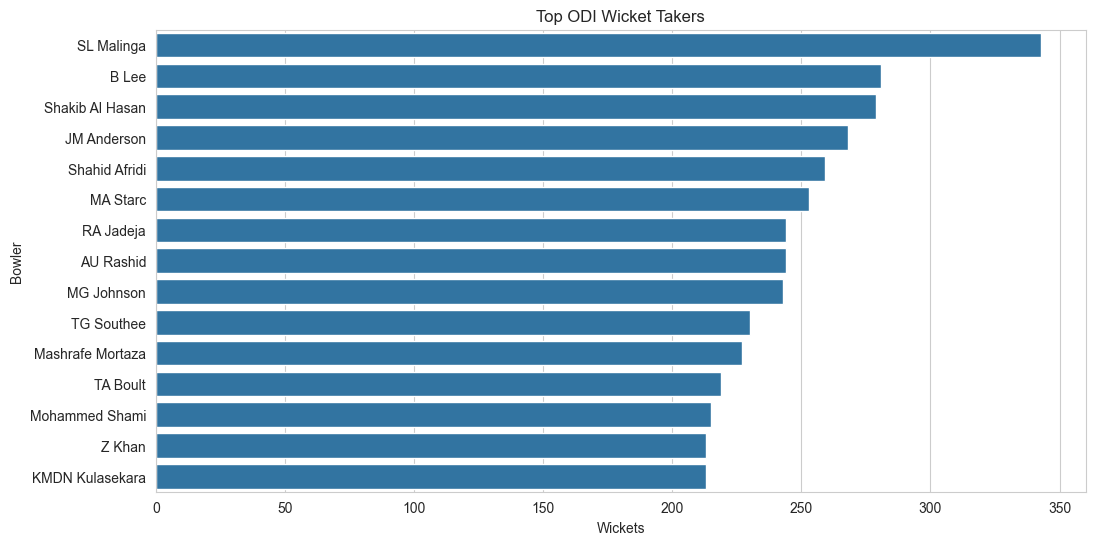

In [71]:
top_wickets = bowling_stats.sort_values("wickets", ascending=False).head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_wickets["wickets"],
    y=top_wickets.index
)

plt.title("Top ODI Wicket Takers")
plt.xlabel("Wickets")
plt.ylabel("Bowler")

plt.show()

#### Bowling Economy vs Strike Rate

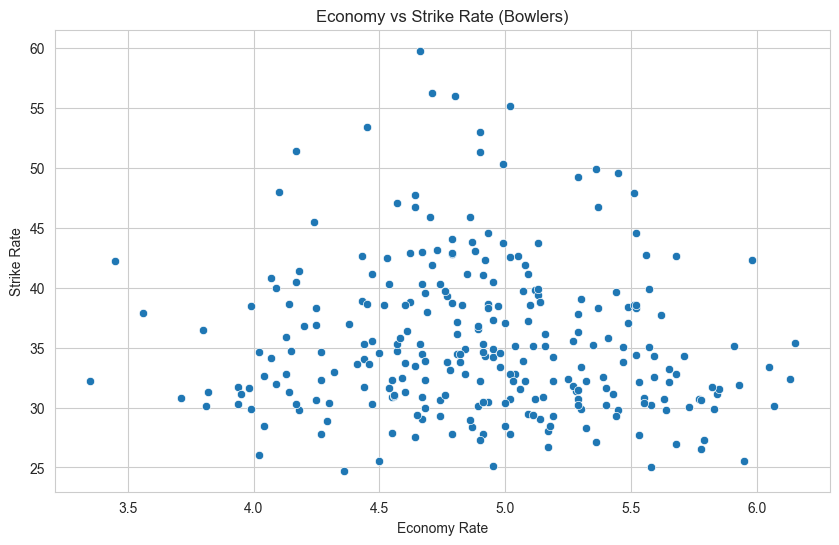

In [75]:
plt.figure(figsize=(10,6))

elite = bowling_stats[bowling_stats["wickets"] > 50]

sns.scatterplot(
    data=elite,
    x="economy",
    y="strike_rate"
)


plt.title("Economy vs Strike Rate (Bowlers)")
plt.xlabel("Economy Rate")
plt.ylabel("Strike Rate")

plt.show()

#### Best Powerplay Bowlers (Wickets in Overs 0-9)

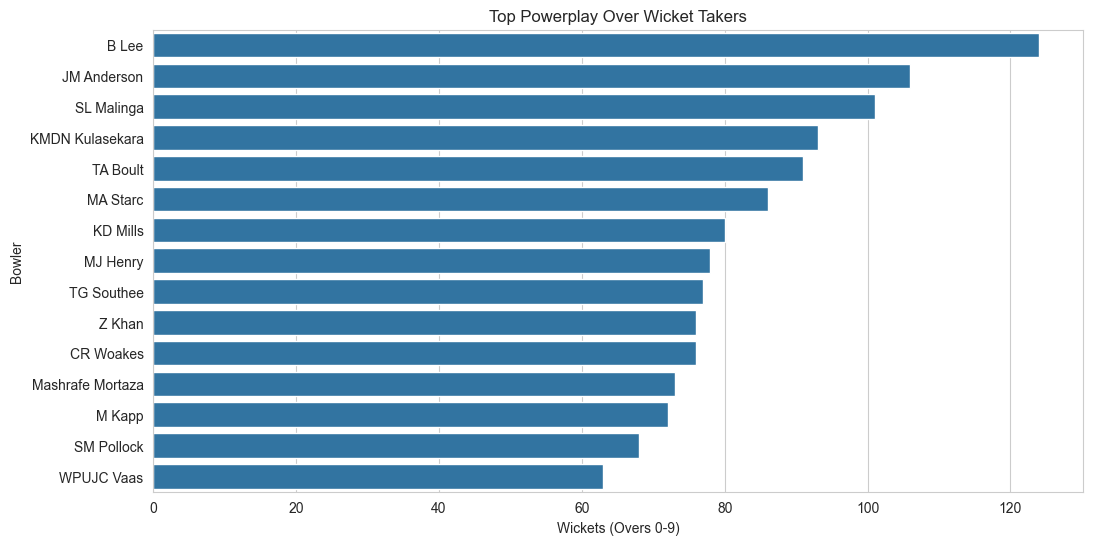

In [76]:
top_powerplay = powerplay_wickets.head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_powerplay.values,
    y=top_powerplay.index
)

plt.title("Top Powerplay Over Wicket Takers")
plt.xlabel("Wickets (Overs 0-9)")
plt.ylabel("Bowler")

plt.show()

#### Best Death Bowlers (Wickets in Overs 40-50)

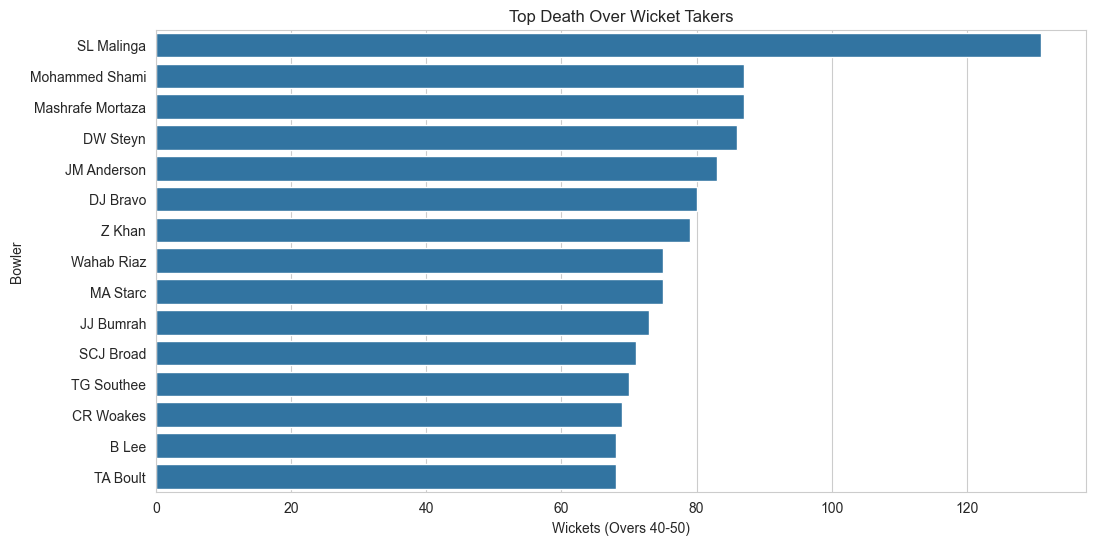

In [77]:
top_death = death_wickets.head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_death.values,
    y=top_death.index
)

plt.title("Top Death Over Wicket Takers")
plt.xlabel("Wickets (Overs 40-50)")
plt.ylabel("Bowler")

plt.show()

#### `Advanced plotting function`

In [101]:
def plot_bowling_stats(bowling_stats, min_balls=500):
    """
    Create comprehensive bowling visualizations
    """
    # Filter for significant bowlers
    bowling_elite = bowling_stats[bowling_stats['balls'] > min_balls].copy()
    
    # Calculate additional metrics
    bowling_elite['wickets_per_match'] = (bowling_elite['wickets'] / bowling_elite['matches']).round(2)
    
    top15_bowlers = bowling_elite.sort_values('wickets', ascending=False).head(15)
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Plot 1: Top wicket-takers
    sns.barplot(
        data=top15_bowlers,
        x='wickets',
        y=top15_bowlers.index if 'bowler' not in top15_bowlers.columns else 'bowler',
        ax=axes[0,0],
        palette='rocket'
    )
    axes[0,0].set_title('Top 15 Wicket Takers', fontsize=14)
    axes[0,0].set_xlabel('Total Wickets')
    
    # Plot 2: Economy vs Average Quadrant
    econ_mean = bowling_elite['economy'].mean()
    avg_mean = bowling_elite['average'].replace([np.inf, -np.inf], 0).mean()
    
    scatter = axes[0,1].scatter(
        bowling_elite['economy'],
        bowling_elite['average'].replace([np.inf, -np.inf], 0),
        s=bowling_elite['wickets']*2,
        alpha=0.6,
        c=bowling_elite['wickets'],
        cmap='viridis_r'
    )
    axes[0,1].axvline(econ_mean, linestyle='--', color='gray', alpha=0.7)
    axes[0,1].axhline(avg_mean, linestyle='--', color='gray', alpha=0.7)
    axes[0,1].set_title('Economy vs Bowling Average', fontsize=14)
    axes[0,1].set_xlabel('Economy Rate')
    axes[0,1].set_ylabel('Bowling Average')
    
    # Add quadrant labels
    axes[0,1].text(econ_mean*0.9, avg_mean*0.9, 'ELITE', fontsize=12, fontweight='bold', color='darkgreen')
    axes[0,1].text(econ_mean*1.1, avg_mean*0.9, 'Economical', fontsize=12)
    axes[0,1].text(econ_mean*0.9, avg_mean*1.1, 'Wicket-taker', fontsize=12)
    axes[0,1].text(econ_mean*1.1, avg_mean*1.1, 'Weak', fontsize=12)
    
    # Plot 3: 4-wicket and 5-wicket hauls
    if '4w' in bowling_elite.columns and '5w' in bowling_elite.columns:
        top15_bowlers.set_index(top15_bowlers.index if 'bowler' not in top15_bowlers.columns else 'bowler')[
            ['4w', '5w']
        ].plot(
            kind='barh',
            stacked=True,
            ax=axes[1,0],
            color=['#f39c12', '#e74c3c']
        )
        axes[1,0].set_title('4-Wicket vs 5-Wicket Hauls', fontsize=14)
        axes[1,0].set_xlabel('Count')
        axes[1,0].legend(['4w', '5w'])
    
    # Plot 4: Strike Rate vs Economy
    sr_mean = bowling_elite['strike_rate'].mean()
    
    scatter2 = axes[1,1].scatter(
        bowling_elite['strike_rate'],
        bowling_elite['economy'],
        s=bowling_elite['wickets']*2,
        alpha=0.6,
        c=bowling_elite['wickets'],
        cmap='plasma'
    )
    axes[1,1].set_title('Bowling Strike Rate vs Economy', fontsize=14)
    axes[1,1].set_xlabel('Strike Rate (balls per wicket)')
    axes[1,1].set_ylabel('Economy Rate')
    
    
    plt.tight_layout()
    plt.suptitle('Bowling Statistics Analysis', fontsize=16, y=1.02)
    plt.show()

C:\Users\sk computers\AppData\Local\Temp\ipykernel_16896\1511757540.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


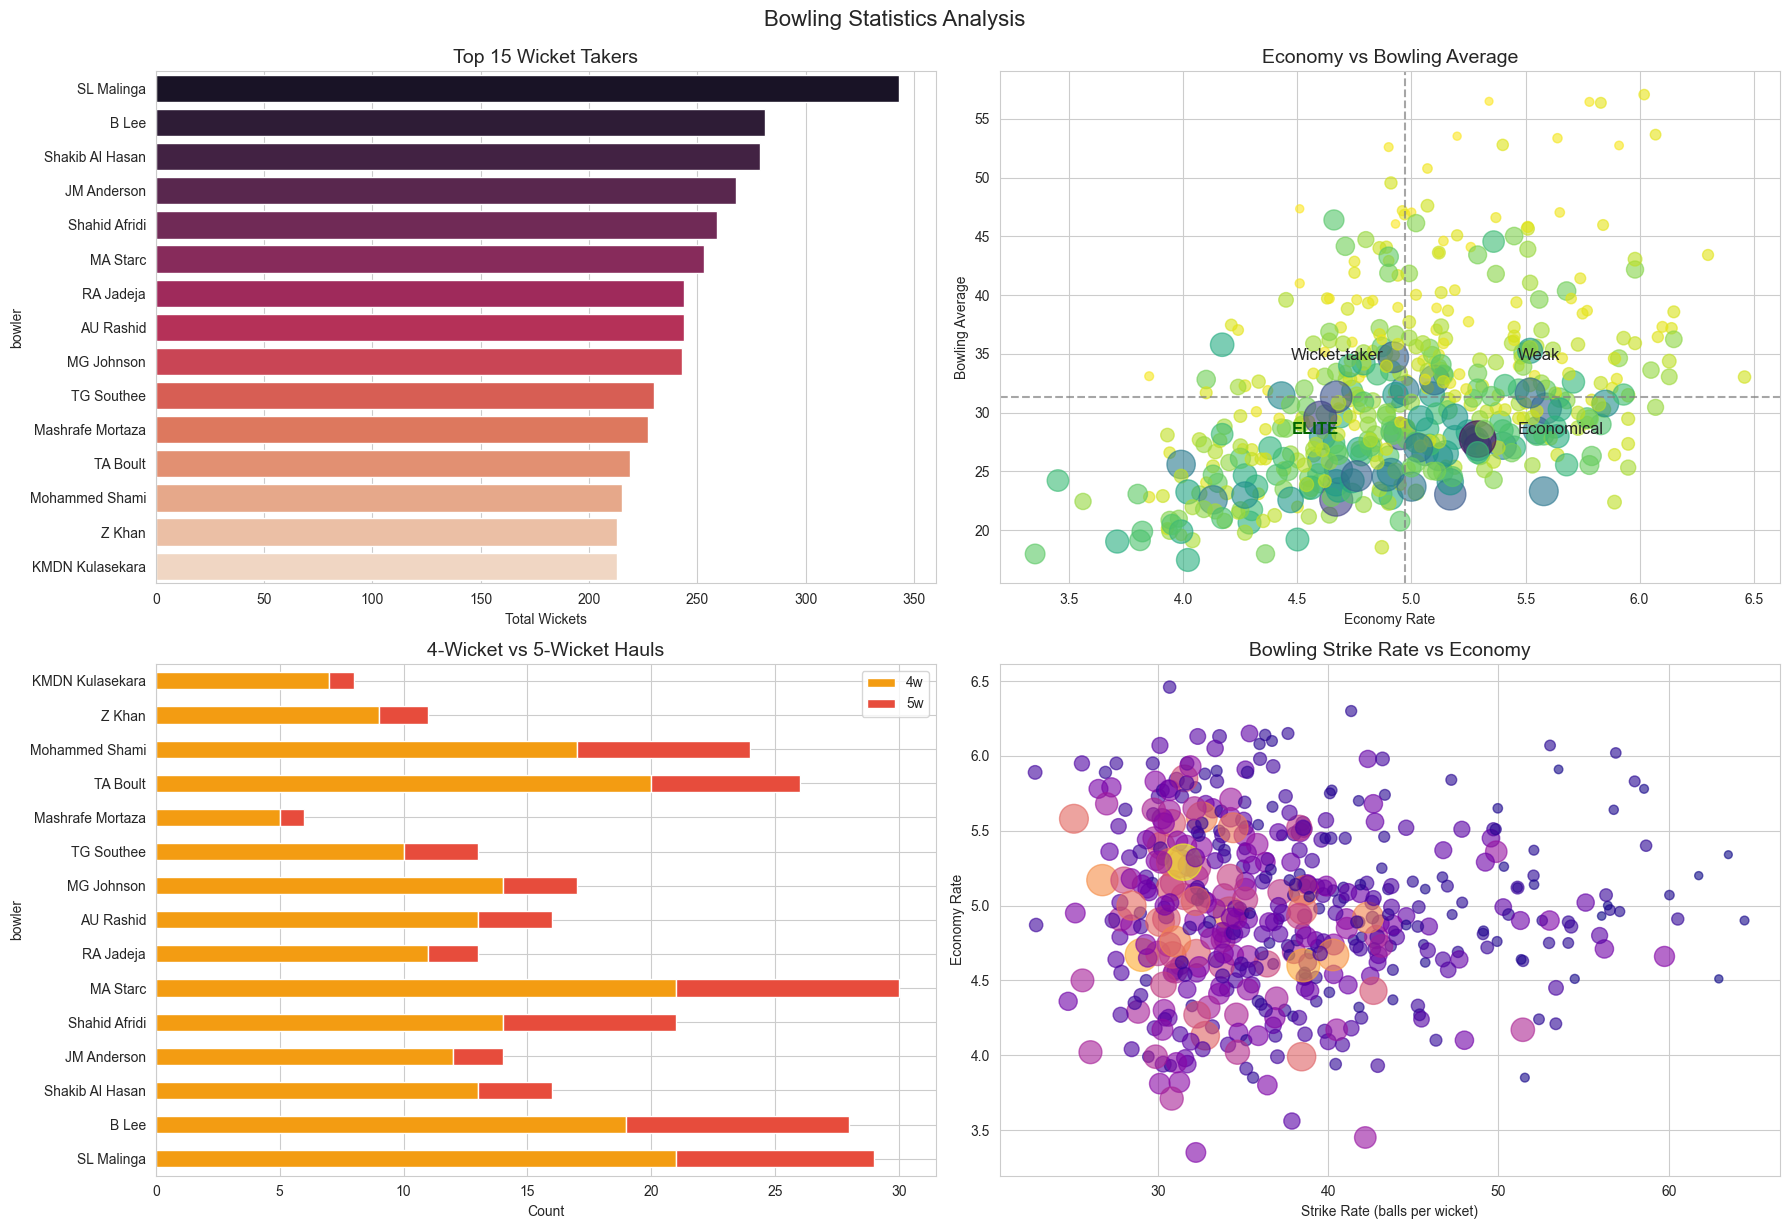

In [102]:
plot_bowling_stats(bowling_stats, min_balls=1000)

In [82]:
bowling_stats.to_csv("../data/bowling_stats.csv", index=True)

In [85]:
df_bowling_stats = pd.read_csv(r"E:\Data analysis projects\cricket_odi_analytics\data\bowling_stats.csv")

In [86]:
df_bowling_stats.head()

,bowler,team,matches,innings,overs,balls,runs_conceded,wickets,economy,average,strike_rate,dot_pct,4w,5w,best_bowling
0,A Dananjaya,Sri Lanka,38,38,337.3,2024,1740,56,5.16,31.07,36.14,49.26,4,2,6/30
1,A Dutt,Netherlands,50,50,410.8,2465,1985,64,4.83,31.02,38.52,57.73,1,1,6/34
2,A Flintoff,England,76,76,649.0,3894,2787,135,4.29,20.64,28.84,59.37,10,3,5/19
3,A Gardner,Australia,83,83,607.2,3643,2608,120,4.30,21.73,30.36,56.38,5,1,5/30
4,A Hartley,England,21,21,170.7,1024,727,27,4.26,26.93,37.93,56.74,1,0,4/37
